# CNN on MNIST: A Teaching Walkthrough

This notebook shows a complete CNN classification workflow on MNIST:
1. Setup and imports
2. Model definition
3. Data preparation
4. Training loop
5. Evaluation and visualization

We keep each section small and focused for easy learning.

In [27]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Reproducibility for teaching/demo consistency
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1) Define the CNN

We use two convolution blocks, then flatten and classify.

Important detail: the model returns raw logits (no Softmax here),
because `CrossEntropyLoss` already applies log-softmax internally.

In [28]:
# Define the model
class CNNModel(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10, mid_channels: int = 16):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(mid_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(mid_channels * 14 * 14, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNModel().to(device)
model

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=10, bias=True)
  )
)

## 2) Prepare MNIST Data

We normalize MNIST with standard mean/std and build DataLoaders
for both training and testing.

In [29]:
# Data transforms and datasets
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


## 3) Train the Model

Training loop checklist:
- Forward pass
- Compute loss
- Backpropagation
- Parameter update

We log average loss and training accuracy per epoch.

In [30]:
# Train the model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

Epoch [1/3] | Loss: 0.2430 | Train Acc: 0.9282
Epoch [2/3] | Loss: 0.0677 | Train Acc: 0.9797
Epoch [3/3] | Loss: 0.0479 | Train Acc: 0.9852


## 4) Evaluate and Visualize Predictions

We compute overall test accuracy and then inspect a small batch of
predictions to build intuition about model behavior.

Test Accuracy: 0.9854


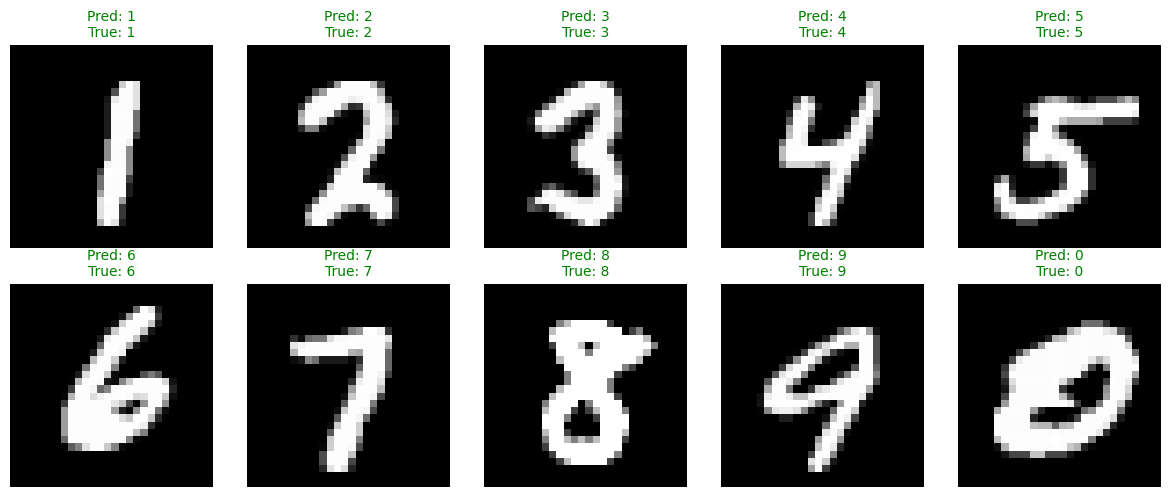

In [31]:
# Evaluate on the test set + visualize a few predictions
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

# Show predictions for one mini-batch
images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images_cpu[i].squeeze() * 0.3081 + 0.1307  # denormalize
    ax.imshow(img, cmap="gray")
    is_correct = preds_cpu[i].item() == labels_cpu[i].item()
    color = "green" if is_correct else "red"
    ax.set_title(
        f"Pred: {preds_cpu[i].item()}\nTrue: {labels_cpu[i].item()}",
        color=color,
        fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()